In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from prophet import Prophet

# Load daily sales
daily_sales = pd.read_csv("../data/features/daily_sales.csv")
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

print("Data loaded!")
print("Shape:", daily_sales.shape)
print("Date range:", daily_sales['Date'].min(), "→", daily_sales['Date'].max())
print("Total days:", len(daily_sales))
print()
print(daily_sales.head())

Data loaded!
Shape: (604, 4)
Date range: 2009-12-01 00:00:00 → 2011-12-09 00:00:00
Total days: 604

        Date   Revenue  Orders  Quantity
0 2009-12-01  43894.87      98     24335
1 2009-12-02  52762.06     110     29679
2 2009-12-03  67413.62     122     48009
3 2009-12-04  33913.81      80     19954
4 2009-12-05   9803.05      30      5119


In [2]:
#Prepare data for Prophet
# Prophet requires exactly two columns: ds (date) and y (value)
df_prophet = daily_sales[['Date', 'Revenue']].copy()
df_prophet.columns = ['ds', 'y']

print("Prophet format ready!")
print("Columns:", list(df_prophet.columns))
print()
print(df_prophet.head())
print()
print("Revenue stats:")
print(f"  Min daily revenue:  £{df_prophet['y'].min():,.2f}")
print(f"  Max daily revenue:  £{df_prophet['y'].max():,.2f}")
print(f"  Avg daily revenue:  £{df_prophet['y'].mean():,.2f}")

Prophet format ready!
Columns: ['ds', 'y']

          ds         y
0 2009-12-01  43894.87
1 2009-12-02  52762.06
2 2009-12-03  67413.62
3 2009-12-04  33913.81
4 2009-12-05   9803.05

Revenue stats:
  Min daily revenue:  £3,439.67
  Max daily revenue:  £184,347.66
  Avg daily revenue:  £28,766.23


In [3]:
# Train Prophet model
model = Prophet(
    yearly_seasonality=True,   # detect Q4 peaks we saw in EDA
    weekly_seasonality=True,   # detect Thursday peaks we saw in EDA
    daily_seasonality=False,   # not needed for daily data
    changepoint_prior_scale=0.05  # controls trend flexibility
)

model.fit(df_prophet)
print("Prophet model trained successfully!")
print()
print("Seasonalities detected:")
print("  Yearly  → Q4 holiday peaks")
print("  Weekly  → Thursday highs, Saturday lows")

13:27:38 - cmdstanpy - INFO - Chain [1] start processing
13:27:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!

Seasonalities detected:
  Yearly  → Q4 holiday peaks
  Weekly  → Thursday highs, Saturday lows


In [4]:
# Create next 90 days for forecasting
future = model.make_future_dataframe(periods=90)

print("Future dataframe created!")
print("Total rows:", len(future))
print("Last known date:", df_prophet['ds'].max().date())
print("Forecast until:", future['ds'].max().date())
print()

# Generate forecast
forecast = model.predict(future)

print("Forecast generated!")
print()
print("Forecast columns:", list(forecast[['ds','yhat','yhat_lower','yhat_upper']].columns))
print()
print("Sample forecast (last 5 rows = future predictions):")
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail())

Future dataframe created!
Total rows: 694
Last known date: 2011-12-09
Forecast until: 2012-03-08

Forecast generated!

Forecast columns: ['ds', 'yhat', 'yhat_lower', 'yhat_upper']

Sample forecast (last 5 rows = future predictions):
            ds          yhat    yhat_lower    yhat_upper
689 2012-03-04  16452.702619   2235.739432  33368.886012
690 2012-03-05  27718.818499  11619.578157  42789.092355
691 2012-03-06  30051.865377  15522.372964  44293.476430
692 2012-03-07  26896.179647  10411.357052  42174.953972
693 2012-03-08  33913.867155  19001.802949  49146.705101


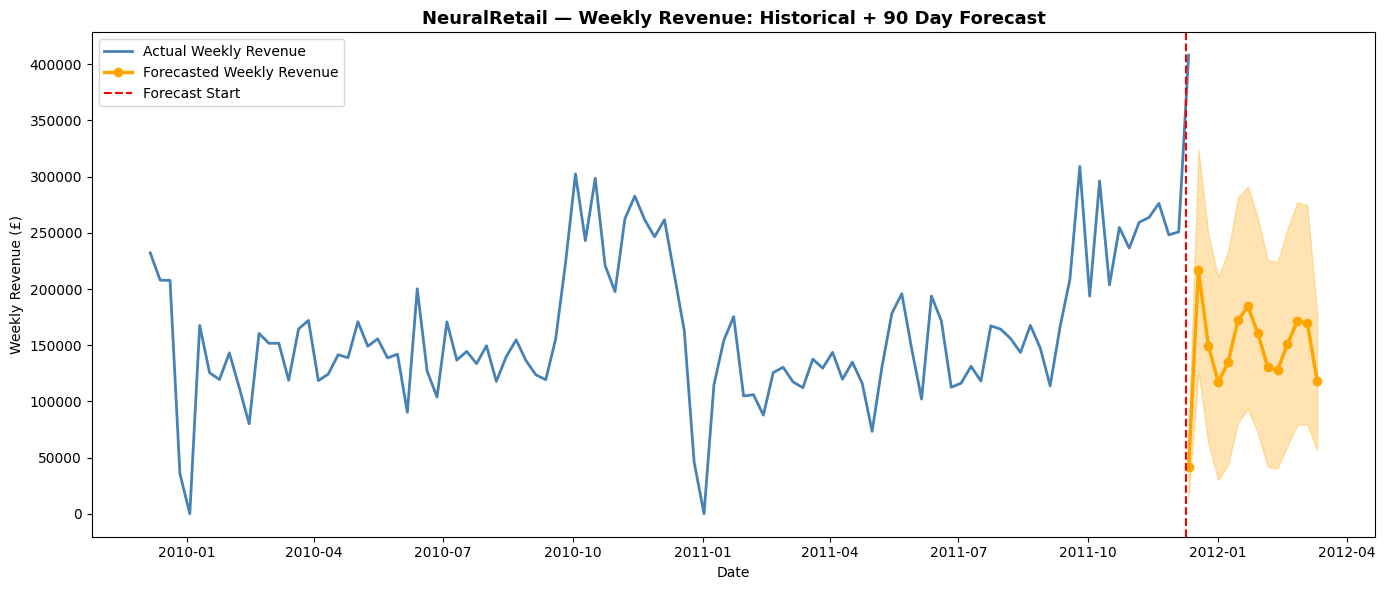

Weekly Forecast Summary:
  Avg historical weekly revenue: £163,913.25
  Avg forecast weekly revenue:   £146,186.78
  Max forecast week:             £216,695.46


In [7]:
# Aggregate forecast to weekly for cleaner view
future_only_clean = future_only.copy()
future_only_clean['yhat'] = future_only_clean['yhat'].clip(lower=0)
future_only_clean['yhat_lower'] = future_only_clean['yhat_lower'].clip(lower=0)
future_only_clean['yhat_upper'] = future_only_clean['yhat_upper'].clip(lower=0)

# Weekly aggregation
future_weekly = future_only_clean.resample('W', on='ds').agg({
    'yhat': 'sum',
    'yhat_lower': 'sum', 
    'yhat_upper': 'sum'
}).reset_index()

# Historical weekly
hist_weekly = df_prophet.copy()
hist_weekly = hist_weekly.resample('W', on='ds')['y'].sum().reset_index()

plt.figure(figsize=(14, 6))

# Historical
plt.plot(hist_weekly['ds'], hist_weekly['y'],
         color='steelblue', linewidth=2, label='Actual Weekly Revenue')

# Forecast
plt.fill_between(future_weekly['ds'],
                 future_weekly['yhat_lower'],
                 future_weekly['yhat_upper'],
                 alpha=0.3, color='orange')
plt.plot(future_weekly['ds'], future_weekly['yhat'],
         color='orange', linewidth=2.5, 
         marker='o', markersize=6, label='Forecasted Weekly Revenue')

# Divider line
plt.axvline(x=df_prophet['ds'].max(), 
            color='red', linestyle='--', linewidth=1.5, label='Forecast Start')

plt.title('NeuralRetail — Weekly Revenue: Historical + 90 Day Forecast',
          fontsize=13, fontweight='bold')
plt.ylabel('Weekly Revenue (£)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/plots/forecast_weekly.png', dpi=150)
plt.show()

print("Weekly Forecast Summary:")
print(f"  Avg historical weekly revenue: £{hist_weekly['y'].mean():,.2f}")
print(f"  Avg forecast weekly revenue:   £{future_weekly['yhat'].mean():,.2f}")
print(f"  Max forecast week:             £{future_weekly['yhat'].max():,.2f}")

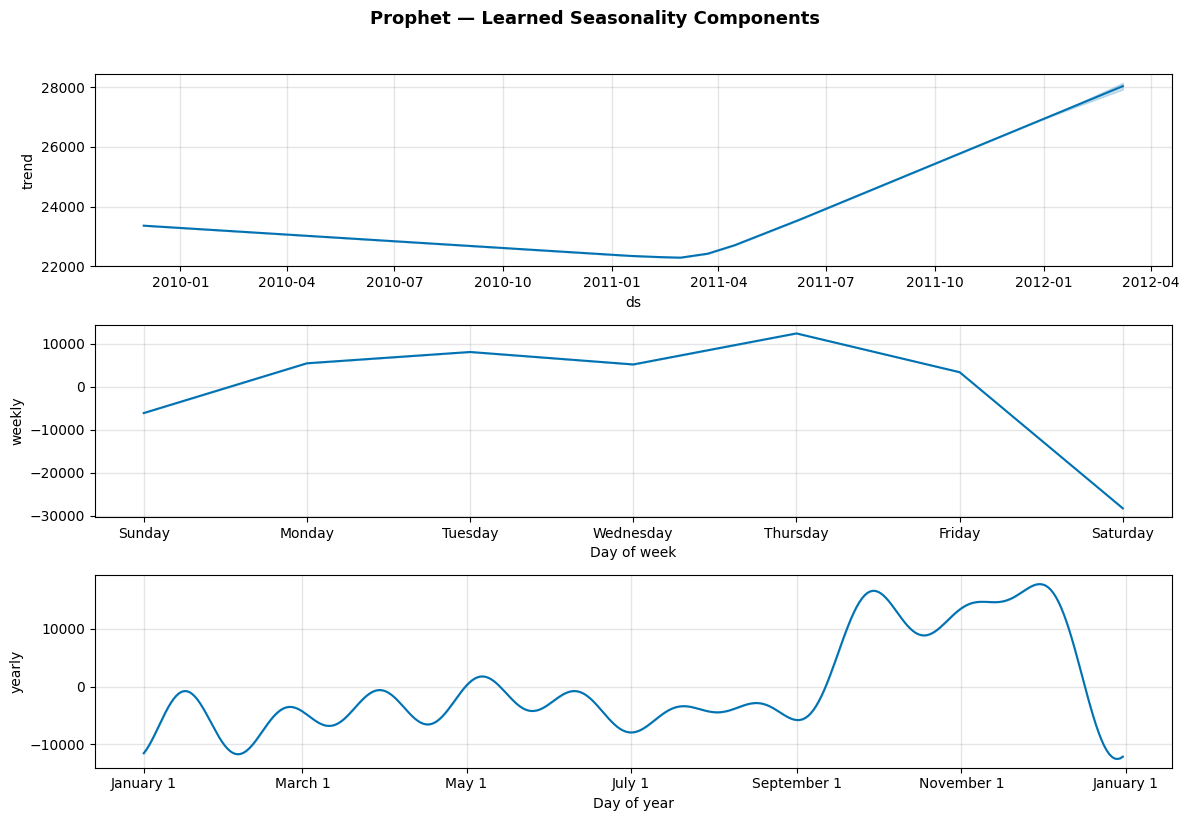

Components plot saved!


In [8]:
# Ploting what Prophet learned about seasonality
fig = model.plot_components(forecast, figsize=(12, 8))
plt.suptitle('Prophet — Learned Seasonality Components', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/plots/forecast_components.png', dpi=150)
plt.show()
print("Components plot saved!")

In [9]:
# Save forecast data
forecast_save = future_only[['ds','yhat','yhat_lower','yhat_upper']].copy()
forecast_save['yhat'] = forecast_save['yhat'].clip(lower=0)
forecast_save['yhat_lower'] = forecast_save['yhat_lower'].clip(lower=0)
forecast_save['yhat_upper'] = forecast_save['yhat_upper'].clip(lower=0)
forecast_save.columns = ['Date','Predicted_Revenue','Lower_Bound','Upper_Bound']
forecast_save.to_csv("../data/features/revenue_forecast.csv", index=False)

print("="*50)
print("   DEMAND FORECASTING COMPLETE")
print("="*50)
print(f"  Model:                    Prophet")
print(f"  Training data:            604 days")
print(f"  Forecast period:          90 days")
print(f"  Forecast until:           2012-03-08")
print()
print(f"  Avg historical daily rev: £{df_prophet['y'].mean():,.2f}")
print(f"  Avg forecast daily rev:   £{forecast_save['Predicted_Revenue'].mean():,.2f}")
print(f"  Max forecast daily rev:   £{forecast_save['Predicted_Revenue'].max():,.2f}")
print()
print("  What Prophet learned:")
print("  → Business growing since mid-2011")
print("  → Thursday always highest day")
print("  → Saturday always near zero")
print("  → Nov-Dec always peak months")
print("  → Jan always lowest month")
print()
print("  File saved: data/features/revenue_forecast.csv")
print("="*50)

   DEMAND FORECASTING COMPLETE
  Model:                    Prophet
  Training data:            604 days
  Forecast period:          90 days
  Forecast until:           2012-03-08

  Avg historical daily rev: £28,766.23
  Avg forecast daily rev:   £22,740.17
  Max forecast daily rev:   £43,296.73

  What Prophet learned:
  → Business growing since mid-2011
  → Thursday always highest day
  → Saturday always near zero
  → Nov-Dec always peak months
  → Jan always lowest month

  File saved: data/features/revenue_forecast.csv
